# Project Final Report

### Due: Midnight on April 27 (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **three components**:

---

### 1. Final Report Notebook [40 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

- **Part A**: Select the single best model from your Milestone 2 experiments. Now that you’ve finalized your model, revisit your decisions from Milestones 1 and 2. Are there any steps you would change—such as cleaning, feature engineering, or model evaluation—given what you now know?

- **Part B**: Write a technical report following standard conventions, for example:
  - [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
  - [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
  - The Checklist given in this week's Blackboard Lesson (essentially the same as in HOML).
    
  Your audience here is technically literate but unfamiliar with your work—like your manager or other data scientists. Be clear, precise, and include both code (for illustration), charts/plots/illustrations, and explanation of what you discovered and your reasoning process. 

The idea here is that Part A would be a repository of the most important code, for further work to come, and Part B is
the technical report which summarizes your project for the data science group at your company. Do NOT assume that readers of Part B are intimately familiar with Part A; provide code for illustration as needed, but not to run.

Submit this notebook as a group via your team leader’s Gradescope account.

---

### 2. PowerPoint Presentation [10 pts]

Create a 10–15 minute presentation designed for a general audience (e.g., sales or marketing team).

- Prepare 8–12 slides, following the general outline of the sections of Part B. 
- Focus on storytelling, visuals (plots and illustrations), and clear, simplified language. No code!
- Use any presentation tool you like, but upload a PDF version.
- List all team members on the first slide.

Submit as a group via your team leader’s Gradescope account.

---

### 3. Individual Assessment

Each team member must complete the Individual Assessment Form (same as in Milestone 1), sign it, and upload it via their own Gradescope account.

---

## Submission Checklist

-  Final Report Notebook — Team leader submission
-  PDF Slides — Team leader submission
-  Individual Assessment Form — Each member submits their own


## Part A: Final Model and Design Reassessment [10 pts]

In this part, you will finalize your best-performing model and revisit earlier decisions to determine if any should be revised in light of your complete modeling workflow. You’ll also consolidate and present the key code used to run your model on the preprocessed dataset, with thoughtful documentation of your reasoning.

**Requirements:**

- Reconsider **at least one decision from Milestone 1** (e.g., preprocessing, feature engineering, or encoding). Explain whether you would keep or revise that decision now that you know which model performs best. Justify your reasoning.
  
- Reconsider **at least one decision from Milestone 2** (e.g., model evaluation, cross-validation strategy, or feature selection). Again, explain whether you would keep or revise your original decision, and why.

- Below, include all code necessary to **run your final model** on the processed dataset. This section should be a clean, readable summary of the most important steps from Milestones 1 and 2, adapted as needed to fit your final model choice and your reconsiderations as just described. 

- Use Markdown cells and inline comments to explain the structure of the code clearly but concisely. The goal is to make your reasoning and process easy to follow for instructors and reviewers.

> Remember: You are not required to change your earlier choices, but you *are* required to reflect on them and justify your final decisions.


In [127]:
# Add as many code cells as you need

In [2]:
# =============================
# Useful Imports (overinclusive to hopefully avoid any issues further down)
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
import kagglehub
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

In [3]:
# Data load in from external source if not already present in your current working directory
url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


In [4]:
# Load in data from local directory (comment out path you are not using)

df = pd.read_csv("/Users/ez873/Documents/Module-3-Assignments-main/zillow_dataset.csv") #Emma

#df = pd.read_csv("zillow_dataset.csv") # Hailey

In [131]:
# Review basic dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [132]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [133]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

This dataset contains 77613 rows (entries) and 55 columns (variables). Some parcel IDs are duplicated (n = 77613 vs nunique = 77414) and will need to be evaluated. This likely indicates multiple sales of the same properties, so we will want to keep the most recent examples to be as accurate as possible to today's market. There are also only 77578 of the 77613 that have values for our target (assessed tax value, variable name "taxvaluedollarcnt"), so we will need to remove the instances with missing or null target values. 

In [134]:
# Feature level EDA

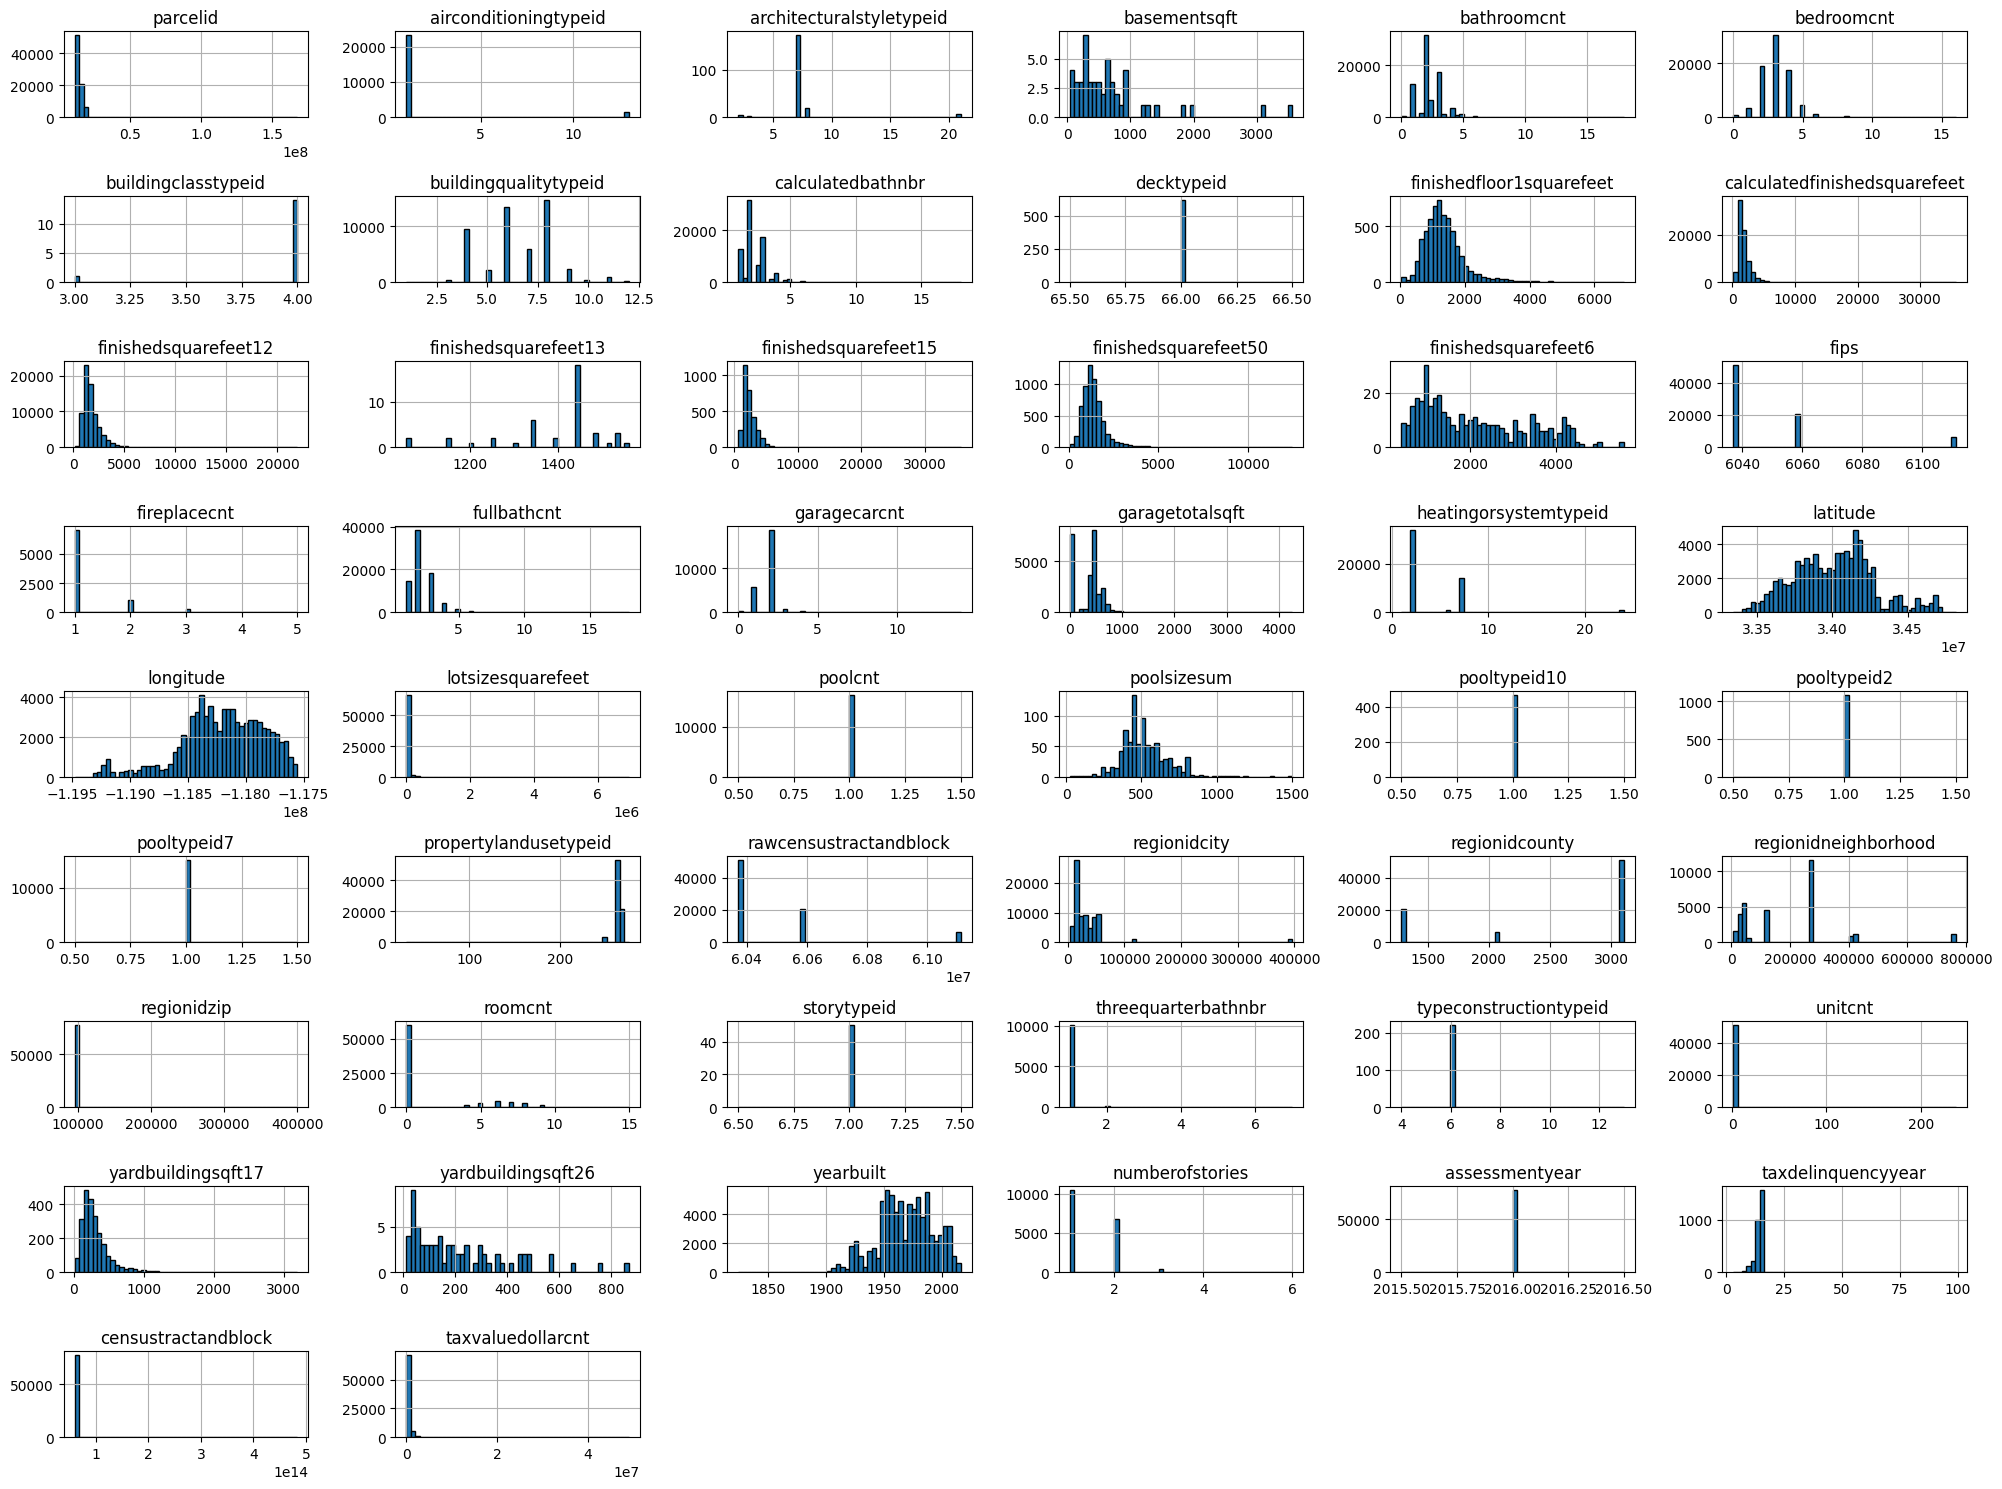

In [135]:
# Histograms of all features to explore distributions and potential features of interest
df.hist(figsize=(20, 15), layout=(-1, 6), bins=50, edgecolor='black')

plt.tight_layout()
plt.show()

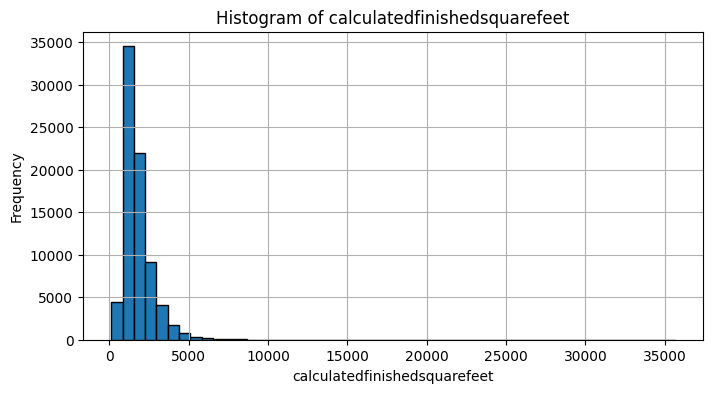

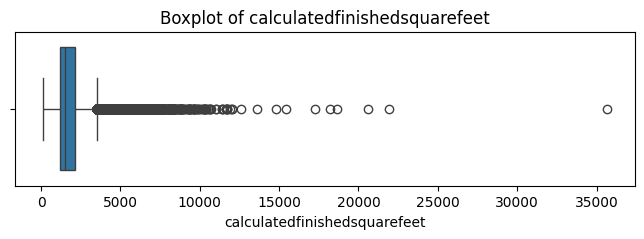

In [136]:
# Feature one: Calculated finished square feet
# This variable is interesting because it is likely to be correlated with property value and the histogram shows a decent amount 
# of spread that will hopefully capture meaningful variance in the target. 

# Specify variable and target
feature = 'calculatedfinishedsquarefeet'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=50, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Here we have a right-skewed distribution with outliers well outside the upper IQR bound.
# Some outliers are very high, fairly spare, and should likely drive results. 

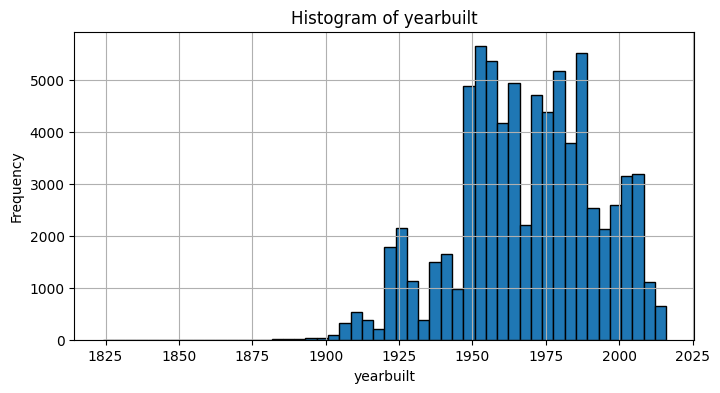

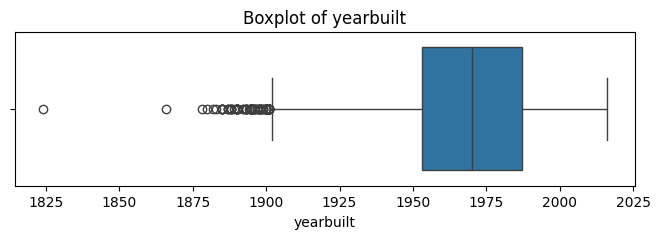

In [137]:
# Feature two: Year built
# This variable is interesting becasue it has a flatter and broader distribution than most others. It also isn't associated with inherent
# value but will indicate more about whether houses from a certain time period are more valuable than others. 

# Specify variable and target
feature = 'yearbuilt'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=50, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Year built is a left-skewed distribution with a handful of early years built. There are a couple of outliers that would skew results in 
# analyses that consider the year built as a numeric variable, but in most use cases this should be categorical.

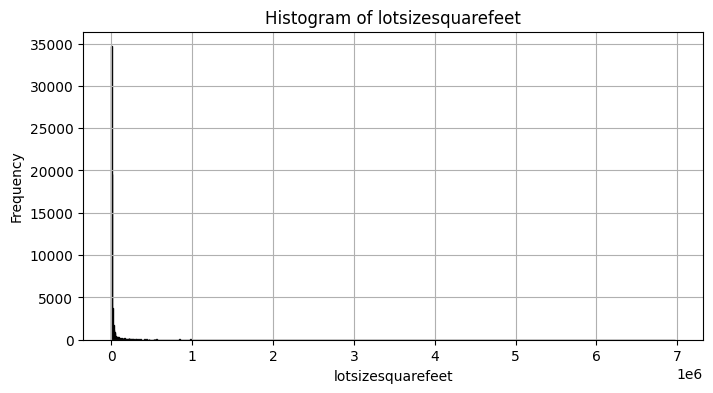

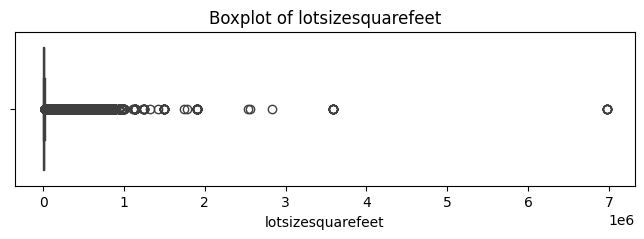

In [138]:
# Feature three: Lot size square feet
# Generally speaking, you pay more to have more so larger lot size is likely to be associated with higher value. It is also interesting
# in that most of the data falls within a narrow range. 

# Specify variable and target
feature = 'lotsizesquarefeet'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=1000, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Lot size has a right-skew distribution with a narrow IQR and a long tail of upper values. There are a few outlier values (approximately 
# those above 1e6) that are sparse enough that they may drive/bias results depending on the analysis.

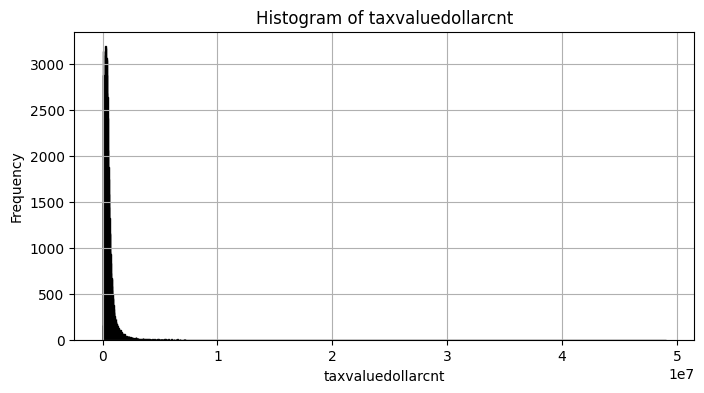

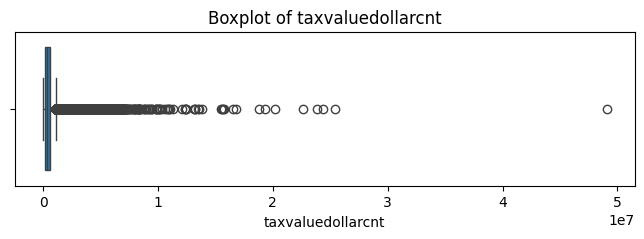

In [139]:
# Target: Tax value dollar cent

# Specify target
target = 'taxvaluedollarcnt'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[target].dropna(), bins=2000, edgecolor='black')
plt.title(f'Histogram of {target}')
plt.xlabel(target)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[target])
plt.title(f'Boxplot of {target}')
plt.show()

# The overall target distribution is most similar to the lot size distribution, demonstrating a right-skew with a long tail and a very 
# narrow IQR. Here too we see upper outliers that become increasingly sparse past about 1.2e7. That said, the range of values seems 
# reasonable as does the overall distribution. 

The features we selected to focus on are calculated finished square feet, year built, and lot size sqare feet. Calculated finished square feet is interesting because it is likely to be correlated with property value and the histogram shows a decent amount of spread that will hopefully capture meaningful variance in the target. The histogram shows a right-skewed distribution with outliers well outside the upper IQR bound. Some outliers are very high, fairly spare, and are likely drive results, depending on which model we use. We selected year built because it has a flatter and broader distribution than most other variables. It also isn't associated with inherent value but can inform us on whether houses from a certain time period are deemed more valuable than others. The histogram shows a left-skewed distribution with a handful of early years built. There are again a couple of outliers that would skew results in analyses that consider the year built as a numeric variable, but in most use cases this should be used as categorical. Generally speaking, you pay more to have more so we selected lot size thinking it is likely to be highly associated with value. It is also interesting in that most of the data falls within a narrow range. Lot size has a right-skew distribution with a narrow IQR and a long tail of upper values. There are a few outlier values (approximately those above 1e6) that are sparse enough that they may drive/bias results depending on the analysis. The overall target distribution looks most similar to the lot size distribution, demonstrating a right-skew with a long tail and a very narrow IQR. Here too we see upper outliers that become increasingly sparse past about 1.2e7. That said, the range of values seems reasonable as does the overall distribution.

WHAT WE ARE DOING DIFFERENTLY
- Initially missed the duplicated IDs, so we need to account for them this time around.
- In Milestone One, our threshold for removing variables with "too many null values" was likely too conservative at 20% null, allowing for relatively few variables to make the cut.
- We are also cleaning our dataset by removing too many null values first and then removing variables from there. 

In [5]:
# This function will list how many nulls occur in which features

def show_null_counts_features(df_input):
    # Count nulls and percentages
    count_nulls = df_input.isnull().sum()
    df_nulls = (df_input.isnull().mean() * 100).round(2)
    
    # Identify variable types
    feature_types = df_input.dtypes.apply(lambda x: 'Numeric' if np.issubdtype(x, np.number) else 'Categorical')
    
    # Construct dataframe of missing data
    missing_data = pd.DataFrame({
        'Feature': count_nulls[count_nulls > 0].index,
        '# Null Values': count_nulls[count_nulls > 0].values, 
        'Null %': df_nulls[df_nulls > 0].values,
        'Type': feature_types[count_nulls > 0].values
    }).sort_values(by='Null %', ascending=False)

    # Display summary
    print(f'The dataset contains {len(df_input)} samples.\n')

    if len(missing_data) == 0:
        print("There are no null values in the dataset!")
    else:
        print('Feature Name    # Nulls      Null %    Type')
        print('------------    -------      ------    ----')
        for _, row in missing_data.iterrows():
            print(f"{row['Feature']:<15} {row['# Null Values']:<12} {row['Null %']:.2f}%   {row['Type']}")

In [6]:
# Initialize a copy of our dataset for cleaning
df_clean = df.copy()

In [7]:
# Remove all rows without a target value ('taxvaluedollarcnt')
df_clean = df_clean.dropna(subset=['taxvaluedollarcnt']).copy()

#show_null_counts_features(df_clean)

In [8]:
# Isolate rows with duplicate IDs
duplicate_rows = df[df.duplicated(subset='parcelid', keep=False)]

# Print all rows with duplicate IDs
#print(duplicate_rows)

In [9]:
# Drop one instance of duplicated rows
df_clean.drop_duplicates(subset='parcelid', keep='last')

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,10833991,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1980.0,NaN,NaN,2016.0,NaN,NaN,6.037132e+13,379000.0
77609,11000655,NaN,NaN,NaN,2.0,2.0,NaN,6.0,2.0,NaN,...,NaN,NaN,1940.0,NaN,NaN,2016.0,NaN,NaN,6.037101e+13,354621.0
77610,17239384,NaN,NaN,NaN,2.0,4.0,NaN,NaN,2.0,NaN,...,656.0,NaN,1964.0,1.0,NaN,2016.0,NaN,NaN,6.111008e+13,67205.0
77611,12773139,1.0,NaN,NaN,1.0,3.0,NaN,4.0,1.0,NaN,...,NaN,NaN,1954.0,NaN,NaN,2016.0,NaN,NaN,6.037434e+13,49546.0


In [145]:
#print(df['propertyzoningdesc'].unique())

In [10]:
max_nulls = 0.6*len(df_clean)      
print(max_nulls)

46546.799999999996


In [147]:
#show_null_counts_features(df_clean)

In [11]:
# The max_nulls limit here is currently set to 60%. Any variable with non-null values for less than 20% of instances will be dropped.
max_nulls = 0.6*len(df_clean)      # We will drop any features with more than max_nulls missing values

# Drop the columns where null count exceeds max_nulls

df_clean2 = df_clean.drop(columns=df_clean.columns[df_clean.isnull().sum() > max_nulls]).copy()

# Uncomment to verify they were removed

show_null_counts_features(df_clean2)

The dataset contains 77578 samples.

Feature Name    # Nulls      Null %    Type
------------    -------      ------    ----
heatingorsystemtypeid 28007        36.10%   Numeric
buildingqualitytypeid 27769        35.79%   Numeric
propertyzoningdesc 27102        34.94%   Categorical
unitcnt         26875        34.64%   Numeric
lotsizesquarefeet 8258         10.64%   Numeric
finishedsquarefeet12 3656         4.71%   Numeric
regionidcity    1472         1.90%   Numeric
calculatedbathnbr 616          0.79%   Numeric
fullbathcnt     616          0.79%   Numeric
yearbuilt       270          0.35%   Numeric
censustractandblock 247          0.32%   Numeric
calculatedfinishedsquarefeet 201          0.26%   Numeric
regionidzip     50           0.06%   Numeric


We do not need an ID column as they are randomly assigned and should not provide any information on the variance. Assessment year is the same or NaN for all and can also be removed. Deck type and text-based variables are also not useful for the regression task.

In [12]:
# Remove irrelevant features
cols_to_drop = ['parcelid', 'assessmentyear', 'decktypeid', 'propertyzoningdesc','longitude','latitude']
existing_cols = [col for col in cols_to_drop if col in df_clean2.columns]

df_clean2 = df_clean2.drop(columns=existing_cols)

Next we will impute values for the remaining nulls.

In [13]:
print(df_clean2.columns.tolist())

['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertycountylandusecode', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'censustractandblock', 'taxvaluedollarcnt']


In [15]:
# Correctly classify categorical variables for imputing
#cols_to_convert = ['buildingqualitytypeid']
#df_clean2[cols_to_convert] = df_clean2[cols_to_convert].astype('category')

In [16]:
#If code above does not run
cols_to_convert = ['airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid',
                   'buildingqualitytypeid', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']

existing_cols = [col for col in cols_to_convert if col in df_clean2.columns]
df_clean2[existing_cols] = df_clean2[existing_cols].astype('category')


In [17]:
# Identify categorical and numeric features
categorical_features = df_clean2.select_dtypes(exclude=['number']).columns.tolist()
numeric_features     = df_clean2.select_dtypes(include=['number']).columns.tolist()

# First make a copy of the cleaned dataset, call it df_imputed
df_imputed = df_clean2.copy()

# Impute numeric columns (using the median)
num_imputer = SimpleImputer(strategy='median')
df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

In [18]:
# Impute numeric columns (using the median)
cat_imputer = SimpleImputer(strategy='most_frequent')
df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])

In [19]:
# Verify: There should be no null values
show_null_counts_features(df_imputed)

The dataset contains 77578 samples.

There are no null values in the dataset!


                         Feature   F-Statistic        P-Value
4           finishedsquarefeet12  42035.783370   0.000000e+00
3   calculatedfinishedsquarefeet  39046.634476   0.000000e+00
2              calculatedbathnbr  22820.073732   0.000000e+00
6                    fullbathcnt  21427.245430   0.000000e+00
0                    bathroomcnt  20937.303354   0.000000e+00
1                     bedroomcnt   4713.271746   0.000000e+00
16                     yearbuilt   1105.190813  1.222386e-240
7          heatingorsystemtypeid    827.393946  5.369273e-181
12                regionidcounty    119.797050   7.344536e-28
9          propertylandusetypeid    100.278591   1.368452e-23
11                  regionidcity     45.726773   1.369107e-11
8              lotsizesquarefeet     29.371450   5.992897e-08
13                   regionidzip     16.358368   5.247483e-05
5                           fips      3.036407   8.141990e-02
10        rawcensustractandblock      2.470593   1.159982e-01
15      

/tmp/ipykernel_6514/342108438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F-Statistic', y='Feature', data=f_stat_df, palette='viridis')


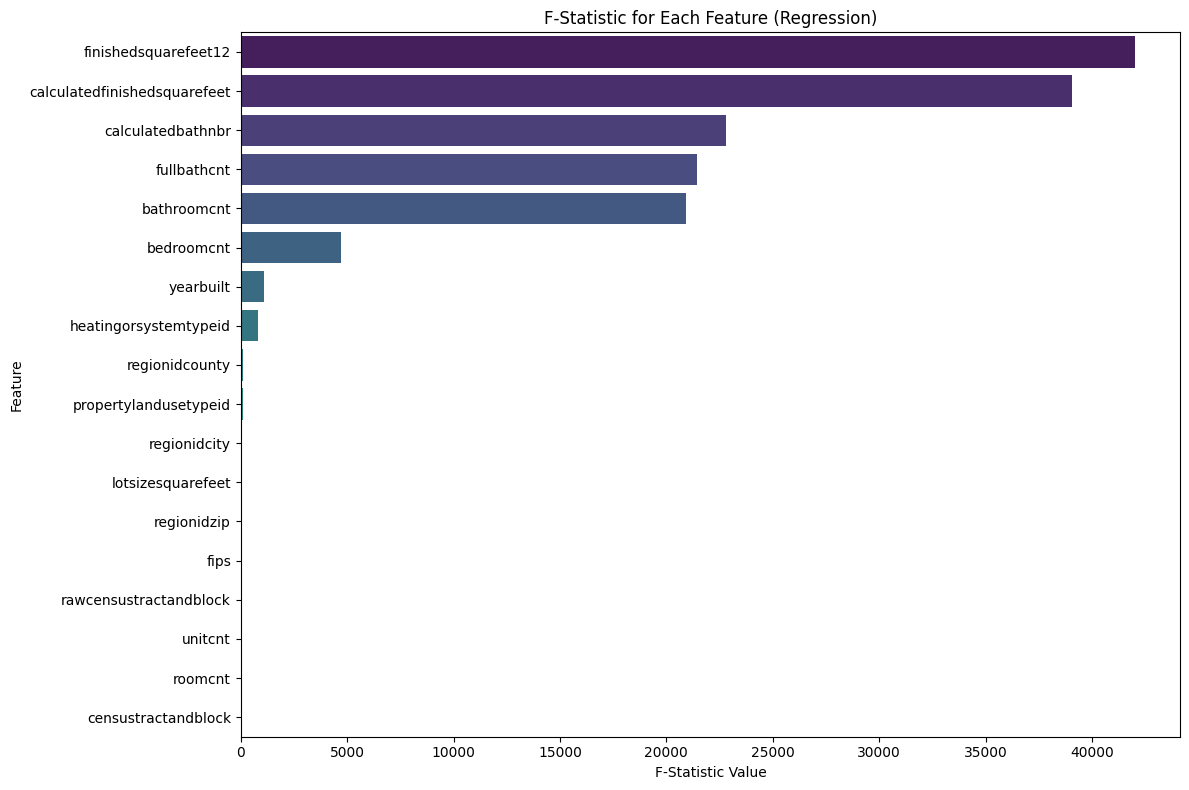

In [156]:
# Compute the F-statistic for all features for a good view of the relationships

from sklearn.feature_selection import f_regression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows with nulls for this analysis
X = df_imputed.drop('taxvaluedollarcnt', axis=1)  
y = df_imputed['taxvaluedollarcnt']

X_numeric = X.select_dtypes(include=[np.number])

# Compute F-statistics for regression
f_values, p_values = f_regression(X_numeric, y)

# Create DataFrame of results
f_stat_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F-Statistic': f_values,
    'P-Value': p_values
}).sort_values(by='F-Statistic', ascending=False)

# Display top results
print(f_stat_df)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='F-Statistic', y='Feature', data=f_stat_df, palette='viridis')
plt.title('F-Statistic for Each Feature (Regression)')
plt.xlabel('F-Statistic Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [20]:
# Check for columns with non-numeric data as the code for baseline modeling would not run. 
non_numeric_columns = df_imputed.select_dtypes(exclude=[np.number]).columns
print("Non-numeric columns:", non_numeric_columns)

# Display the first few rows of any non-numeric columns
for col in non_numeric_columns:
    print(f"\n{col}:")
    print(df_imputed[col].head())


Non-numeric columns: Index(['buildingqualitytypeid', 'propertycountylandusecode'], dtype='object')

buildingqualitytypeid:
0    8.0
1    8.0
2    8.0
3    8.0
4    8.0
Name: buildingqualitytypeid, dtype: object

propertycountylandusecode:
0     122
1    1110
2     122
3    0101
4    010C
Name: propertycountylandusecode, dtype: object


In [21]:
# Using LabelEncoder to address the 'propertycountylandusecode' column

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

df_imputed['propertycountylandusecode'] = label_encoder.fit_transform(df_imputed['propertycountylandusecode'])

print(df_imputed.dtypes)


bathroomcnt                     float64
bedroomcnt                      float64
buildingqualitytypeid            object
calculatedbathnbr               float64
calculatedfinishedsquarefeet    float64
finishedsquarefeet12            float64
fips                            float64
fullbathcnt                     float64
heatingorsystemtypeid           float64
lotsizesquarefeet               float64
propertycountylandusecode         int64
propertylandusetypeid           float64
rawcensustractandblock          float64
regionidcity                    float64
regionidcounty                  float64
regionidzip                     float64
roomcnt                         float64
unitcnt                         float64
yearbuilt                       float64
censustractandblock             float64
taxvaluedollarcnt               float64
dtype: object


In [22]:
#Converting 'buildingqualitytypeid' to numeric to address error.

df_imputed['buildingqualitytypeid'] = pd.to_numeric(df_imputed['buildingqualitytypeid'])

# Check the changes
print(df[['buildingqualitytypeid']].head())


   buildingqualitytypeid
0                    NaN
1                    NaN
2                    NaN
3                    8.0
4                    8.0


In [23]:
#Splitting cleaned data into training and test sets

from sklearn.model_selection import train_test_split

X = df_imputed.drop('taxvaluedollarcnt', axis=1)  
y = df_imputed['taxvaluedollarcnt']               

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (62062, 20)
y_train shape: (62062,)


In [24]:
# Default Parameters to use going forward
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

In [28]:
#Linear Regression after standardization

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Encode categorical variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

lr = LinearRegression()

neg_mse_scores = cross_val_score(lr, X_train_encoded, y_train, cv=repeated_cv, scoring='neg_mean_squared_error')

mse_scores = -neg_mse_scores

rmse_scores = np.sqrt(mse_scores)

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print(f'Mean CV RMSE for Linear Regression: ${mean_rmse:,.2f}')
print(f'Standard Deviation CV RMSE for Linear Regression: ${std_rmse:,.2f}')

Mean CV RMSE for Linear Regression: $552,342.97
Standard Deviation CV RMSE for Linear Regression: $209,442.62


In [29]:
#Bagging after standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)

br = BaggingRegressor()

neg_mse_scores = cross_val_score(br, X_train_scaled, y_train, cv=repeated_cv, scoring='neg_mean_squared_error')

mse_scores = -neg_mse_scores
rmse_scores = np.sqrt(mse_scores)

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print(f'Mean CV RMSE for Bagging Regressor : ${mean_rmse:,.2f}')
print(f'Standard Deviation CV RMSE for Bagging Regressor: ${std_rmse:,.2f}')



Mean CV RMSE for Bagging Regressor : $413,876.29
Standard Deviation CV RMSE for Bagging Regressor: $16,310.25


In our original code we utilized RMSE to evaulate the model; we still believe that was a good choice as it offers a clear measure of the model error. In addition, we believed our cross validation strategy of using RepeatedKFold was a good choice as it provides a reliable estimate of the model performance. However, if time and money were of concern, it would have been beneficial to use a less robust strategy such as Kfold with fewer splits.

WHAT WE WOULD DO DIFFERENTLY:

Specifically looking at our best model, Bagging Regressor, we see its worse performance was with polynomial terms. This is most likely due to the fact that polynomial features can increase the complexity of the model and result in overfitting and high varience. Instead of using polynomial terms, we could have used discretization or binning; this could help the model capture trends without overfitting to noise.

In [30]:
#NEW! Binning with Bagging Regressor instead of polynomial terms

# 1. Binning 'calculatedfinishedsquarefeet'
X_train['squarefeet_bin'] = pd.cut(X_train['calculatedfinishedsquarefeet'],
                                   bins=[0, 1000, 2000, 3000, 4000, np.inf],
                                   labels=['Small', 'Medium', 'Large', 'X-Large', 'XX-Large'])

# 2. Binning 'lotsizesquarefeet'
X_train['lotsize_bin'] = pd.cut(X_train['lotsizesquarefeet'],
                                bins=[0, 5000, 10000, 20000, 40000, np.inf],
                                labels=['Tiny', 'Small', 'Medium', 'Large', 'Huge'])

# 3. Binning 'yearbuilt'
X_train['yearbuilt_bin'] = pd.cut(X_train['yearbuilt'],
                                  bins=[0, 1950, 1970, 1990, 2010, np.inf],
                                  labels=['Old', 'Mid-Century', 'Modern', 'Contemporary', 'New'])



br = BaggingRegressor()
neg_mse_scores_bagging_binning = cross_val_score(br, X_train_scaled, y_train, 
                                         scoring='neg_mean_squared_error', 
                                         cv=repeated_cv)

mse_scores_bagging_binning = -neg_mse_scores_bagging_binning
rmse_scores_bagging_binning = np.sqrt(mse_scores_bagging_binning)
mean_rmse_bagging_binning = np.mean(rmse_scores_bagging_binning)
std_rmse_bagging_binning = np.std(rmse_scores_bagging_binning)


print(f'Mean CV RMSE for Bagging with Binning : ${mean_rmse_bagging_binning:,.2f}')
print(f'Standard Deviation CV RMSE for Bagging with Binninng: ${std_rmse_bagging_binning:,.2f}')

Mean CV RMSE for Bagging with Binning : $414,800.82
Standard Deviation CV RMSE for Bagging with Binninng: $17,259.99


In [31]:
import numpy as np
from sklearn.model_selection import train_test_split

X = df_imputed.drop('taxvaluedollarcnt', axis=1)  
y = df_imputed['taxvaluedollarcnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train['log_yearbuilt'] = np.log1p(X_train['yearbuilt'])



In [32]:
# Log transform the 'YearBuilt' feature 

X_train['log_yearbuilt'] = np.log(X_train['yearbuilt'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [33]:
# Bagging Regressor with Log Transform yearbuilt
bagging = BaggingRegressor()
neg_mse_scores_bag = cross_val_score(bagging, X_scaled, y_train, cv=repeated_cv, scoring='neg_mean_squared_error')
mse_scores_bag = -neg_mse_scores_bag
rmse_scores_bag = np.sqrt(mse_scores_bag)

mean_rmse_bag = np.mean(rmse_scores_bag)
std_rmse_bag = np.std(rmse_scores_bag)

print(f'Mean CV RMSE for Bagging Regressor : ${mean_rmse_bag:,.2f}')
print(f'Standard Deviation CV RMSE for Bagging Regressor: ${std_rmse_bag:,.2f}')

Mean CV RMSE for Bagging Regressor : $414,531.65
Standard Deviation CV RMSE for Bagging Regressor: $16,349.28


In [34]:
# Interaction term
X_train['bath_bedroom_interaction'] = X_train['bathroomcnt'] * X_train['bedroomcnt']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [36]:
# Bagging with Interaction Terms
bagging_regressor_interaction = BaggingRegressor()

neg_mse_scores_bagging_interaction = cross_val_score(bagging_regressor_interaction, X_scaled, y_train, cv=repeated_cv, scoring='neg_mean_squared_error')
mse_scores_bagging_interaction = -neg_mse_scores_bagging_interaction
rmse_scores_bagging_interaction = np.sqrt(mse_scores_bagging_interaction)

mean_rmse_bagging_interaction = np.mean(rmse_scores_bagging_interaction)
std_rmse_bagging_interaction = np.std(rmse_scores_bagging_interaction)

print(f'Mean CV RMSE for Bagging Regressor with Interaction Terms: ${mean_rmse_bagging_interaction:,.2f}')
print(f'Standard Deviation CV RMSE for Bagging Regressor with Interaction Terms: ${std_rmse_bagging_interaction:,.2f}')


Mean CV RMSE for Bagging Regressor with Interaction Terms: $415,410.62
Standard Deviation CV RMSE for Bagging Regressor with Interaction Terms: $16,016.68


In [37]:
def run_model(model, X_train, y_train, X_test, y_test, n_repeats=10, n_jobs=-1, **model_params):

    # Instantiate the model if a class is provided, so for example can use either BaggingRegressor or BaggingRegressor() as argument. 
    if isinstance(model, type):
        model = model(**model_params)

    neg_mse_scores = cross_val_score(model, X_train, y_train,scoring = 'neg_mean_squared_error',
                                     cv = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=42), n_jobs  = n_jobs)
    
    mean_cv_mse = -np.mean(neg_mse_scores)
    std_cv_mse  = np.std(neg_mse_scores)
    
    # Fit the model on the full training set
    model.fit(X_train, y_train)
    
    # Compute training MSE and testing MSE
    train_preds = model.predict(X_train)
    train_mse   = mean_squared_error(y_train, train_preds)
    test_preds  = model.predict(X_test)
    test_mse    = mean_squared_error(y_test, test_preds)
    
    return mean_cv_mse, std_cv_mse, train_mse, test_mse

Selected Features: ['lotsizesquarefeet'] with RMSE: 681176.46
Selected Features: ['lotsizesquarefeet', 'roomcnt'] with RMSE: 694775.40
Selected Features: ['lotsizesquarefeet', 'roomcnt', 'heatingorsystemtypeid'] with RMSE: 696993.62
Selected Features: ['lotsizesquarefeet', 'roomcnt', 'heatingorsystemtypeid', 'regionidcounty'] with RMSE: 682217.18
Selected Features: ['lotsizesquarefeet', 'roomcnt', 'heatingorsystemtypeid', 'regionidcounty', 'fips'] with RMSE: 681140.84
Selected Features: ['lotsizesquarefeet', 'roomcnt', 'heatingorsystemtypeid', 'regionidcounty', 'fips', 'unitcnt'] with RMSE: 677378.85
Selected Features: ['lotsizesquarefeet', 'roomcnt', 'heatingorsystemtypeid', 'regionidcounty', 'fips', 'unitcnt', 'propertylandusetypeid'] with RMSE: 655414.10
Selected Features: ['lotsizesquarefeet', 'roomcnt', 'heatingorsystemtypeid', 'regionidcounty', 'fips', 'unitcnt', 'propertylandusetypeid', 'bedroomcnt'] with RMSE: 635602.96
Selected Features: ['lotsizesquarefeet', 'roomcnt', 'heati

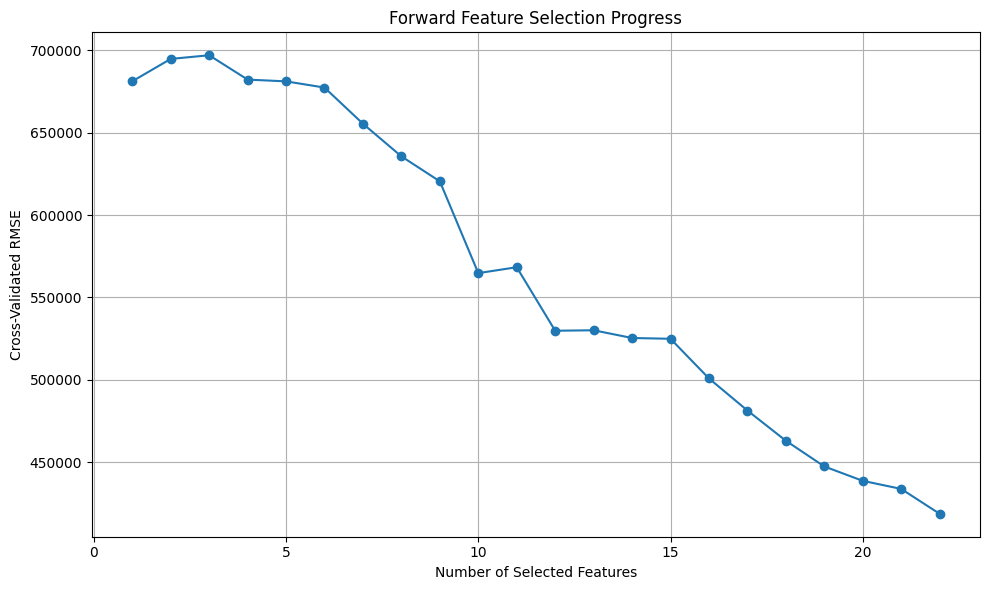

In [44]:
# # Investigate forward feature selection Bagging
X_train_scaled_df = pd.DataFrame(X_scaled, columns=X_train.columns, index=X_train.index)
X = X_train_scaled_df
y = y_train

model = BaggingRegressor()

selected_features = []
remaining_features = list(X.columns)

rmse_scores = []  # Store RMSE scores here
steps = []        # Store step numbers

while remaining_features:
    scores = []
    
    for feature in remaining_features:
        features_to_test = selected_features + [feature]
        
        score = cross_val_score(model, X[features_to_test], y, cv=5, scoring='neg_mean_squared_error').mean()
        
        scores.append((score, feature))
    
    scores.sort()
    
    best_score, best_feature = scores[0]
    
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    rmse = np.sqrt(abs(best_score))
    rmse_scores.append(rmse)
    steps.append(len(selected_features))

    print(f"Selected Features: {selected_features} with RMSE: {rmse:.2f}")

print("\nFinal selected features:", selected_features)

# Plot RMSE vs number of features
plt.figure(figsize=(10, 6))
plt.plot(steps, rmse_scores, marker='o')
plt.xlabel('Number of Selected Features')
plt.ylabel('Cross-Validated RMSE')
plt.title('Forward Feature Selection Progress')
plt.grid(True)
plt.tight_layout()
plt.show()

Bagging models do not necessarily need forward or backward selection as this model already works by training and splitting random subsets of data and averaging their predictions. In other words, bagging already goes through the selection process and we could limit computing time and cost by forgoing its use with this model. 

However, forward or backward selection can be very helpful with the linear regression model. Below is the comparison between forward and backward selection for that model. It appears that the forward selection produced a lower RMSE, which is a decision we are glad we made in our analysis.

In [195]:
# Investigate forward feature selection with Linear Regression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_imputed.drop('taxvaluedollarcnt', axis=1) 
y = df_imputed['taxvaluedollarcnt']

model = LinearRegression()

selected_features = []
remaining_features = list(X_numeric.columns)

best_score = np.inf  

while remaining_features:
    scores = []
    
    for feature in remaining_features:
        features_to_test = selected_features + [feature]
        
        score = cross_val_score(model, X[features_to_test], y, cv=5, scoring='neg_mean_squared_error').mean()
        
        scores.append((score, feature))
    
    scores.sort()
    
    best_score, best_feature = scores[0]
    
    selected_features.append(best_feature)
    
    remaining_features.remove(best_feature)

    print(f"Selected Features: {selected_features} with Negative MSE: {best_score:.4f}")

print("Final selected features:", selected_features)


Selected Features: ['censustractandblock'] with Negative MSE: -428289490246.4297
Selected Features: ['censustractandblock', 'rawcensustractandblock'] with Negative MSE: -667343478819.3717
Selected Features: ['censustractandblock', 'rawcensustractandblock', 'propertylandusetypeid'] with Negative MSE: -672796428722.4734
Selected Features: ['censustractandblock', 'rawcensustractandblock', 'propertylandusetypeid', 'regionidcity'] with Negative MSE: -674010136832.4797
Selected Features: ['censustractandblock', 'rawcensustractandblock', 'propertylandusetypeid', 'regionidcity', 'roomcnt'] with Negative MSE: -675124316013.0498
Selected Features: ['censustractandblock', 'rawcensustractandblock', 'propertylandusetypeid', 'regionidcity', 'roomcnt', 'bedroomcnt'] with Negative MSE: -675822943947.3168
Selected Features: ['censustractandblock', 'rawcensustractandblock', 'propertylandusetypeid', 'regionidcity', 'roomcnt', 'bedroomcnt', 'regionidzip'] with Negative MSE: -676027277178.6541
Selected Fea

In [196]:
# Investigate backward feature selection

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_imputed.drop('taxvaluedollarcnt', axis=1) 
y = df_imputed['taxvaluedollarcnt']

model = LinearRegression()

selected_features = list(X_numeric.columns)
remaining_features = selected_features.copy()

best_score = np.inf  

while len(remaining_features) > 0:
    scores = []
    
    for feature in remaining_features:
        features_to_test = [f for f in selected_features if f != feature]
        
        if len(features_to_test) == 0:
            continue
        
        score = cross_val_score(model, X[features_to_test], y, cv=5, scoring='neg_mean_squared_error').mean()
        
        scores.append((score, feature))
    
    if scores:
        scores.sort()
        best_score, worst_feature = scores[0]
        
        selected_features.remove(worst_feature)
        remaining_features.remove(worst_feature)

        print(f"Selected Features: {selected_features} with Negative MSE: {best_score:.4f}")
    else:
        break

print("Final selected features:", selected_features)


Selected Features: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'censustractandblock'] with Negative MSE: -331575369387.2789
Selected Features: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'censustractandblock'] with Negative MSE: -338970724873.9583
Selected Features: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'censustractandblock'] with Negative MSE: -50588313802

In [45]:
X_train_BR = X_train_scaled_df[['lotsizesquarefeet', 'regionidcounty', 'heatingorsystemtypeid', 'fips', 'unitcnt', 'roomcnt', 'propertylandusetypeid', 'bedroomcnt', 'propertycountylandusecode', 'yearbuilt', 'log_yearbuilt', 'buildingqualitytypeid', 'fullbathcnt', 'bathroomcnt', 'calculatedbathnbr', 'bath_bedroom_interaction', 'regionidcity', 'rawcensustractandblock', 'censustractandblock', 'regionidzip', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12']]

br = BaggingRegressor()

neg_mse_scores = cross_val_score(br, X_train_BR, y_train, cv=repeated_cv, scoring='neg_mean_squared_error')

mse_scores = -neg_mse_scores

rmse_scores = np.sqrt(mse_scores)

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print(f'Mean CV RMSE for Bagging Regressor: ${mean_rmse:,.2f}')
print(f'Standard Deviation CV RMSE for Bagging Regressor: ${std_rmse:,.2f}')

Mean CV RMSE for Bagging Regressor: $413,325.01
Standard Deviation CV RMSE for Bagging Regressor: $16,852.09


In [39]:
# sweep_params for train only

def sweep_parameter(model,
                    Parameters,
                    param,
                    parameter_list,
                    X_train          = X_train,
                    y_train          = y_train,
                    verbose          = True,
                    show_rmse        = True,
                    n_iter_no_change = None,
                    delta            = 0.001,
                    n_jobs           = -1,
                    n_repeats        = 10):
    
    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary
    
    cv_mses, std_cvs, train_mses = [], [], []
    no_improve_count = 0
    best_mse = float('inf')
    
    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        # Remove MSE_found if present, just in case
        P_temp.pop('MSE_found', None)
        
        cv_mse, std_cv, train_mse = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_mses.append(cv_mse)
        std_cvs.append(std_cv)
        train_mses.append(train_mse)
        
        # Early-stopping logic
        if cv_mse < best_mse - delta:
            best_mse = cv_mse
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break
    
    # Identify best parameter
    min_cv_mse = min(cv_mses)
    min_index = cv_mses.index(min_cv_mse)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MSE_found'] = min_cv_mse
    
    if verbose:
        # Prepare for plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        
        # We only need as many parameter values as we actually computed
        partial_param_list = parameter_list[:len(cv_mses)]
        
        # Check if our parameter list is Boolean so we can label accordingly
        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            # Convert booleans to integer indices for plotting
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            # Treat numeric or other types as-is
            x_vals = partial_param_list
            x_labels = partial_param_list
        
        error_name = 'RMSE' if show_rmse else 'MSE'
        
        # ----- First plot: (R)MSE -----
        ax1.set_title(f"{error_name} vs {param}")
        
        # Apply dollar formatting ONLY if we're showing RMSE
        if show_rmse:
            ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
        
        # Plot lines
        ax1.plot(x_vals,
                 np.sqrt(cv_mses) if show_rmse else cv_mses,
                 marker='.', label=f"CV {error_name}", color='blue')
        ax1.plot(x_vals,
                 np.sqrt(train_mses) if show_rmse else train_mses,
                 marker='.', label=f"Train {error_name}", color='green')
        ax1.scatter([x_vals[min_index]],
                    [np.sqrt(min_cv_mse) if show_rmse else min_cv_mse],
                    marker='x', label=f"Best CV {error_name}", color='red')
        
        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()
        
        # ----- Second plot: CV Std Dev -----
        ax2.set_title(f"CV Standard Deviation vs {param}")
        ax2.plot(x_vals, std_cvs, marker='.', label=f"CV {error_name} Std", color='blue')
        ax2.set_xlabel(param)
        ax2.set_ylabel("Standard Deviation")
        ax2.legend()
        ax2.grid(alpha=0.5)
        
        # If we are using boolean x-values, set custom ticks
        if is_boolean:
            ax2.set_xticks(x_vals)
            ax2.set_xticklabels(x_labels)
        
        plt.tight_layout()
        plt.show()
        
        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))
    
    return Parameters


In [57]:
# Run model for test OR train-only

def run_model(model, X_train, y_train, n_repeats=10, n_jobs=-1, **model_params):
    model_instance = model(**model_params)
    
    rkf = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=42)
    cv_scores = cross_val_score(model_instance, X_train, y_train,
                                 scoring='neg_mean_squared_error',
                                 cv=rkf, n_jobs=n_jobs)
    
    model_instance.fit(X_train, y_train)
    train_preds = model_instance.predict(X_train)
    train_mse = mean_squared_error(y_train, train_preds)
    
    return -cv_scores.mean(), cv_scores.std(), train_mse

In [42]:
#Finding Best Parameters 

start = time.time()

# Define parameter grid correctly using dictionary syntax
param_grid = {
    'n_estimators': range(465, 486, 5), 
    'max_samples': np.linspace(0.2, 0.3, 5).tolist(),  
    'max_features': range(18,22, 1),  
    'bootstrap': [True]  # Fixed value
}

# Initialize BaggingRegressor
bagging_regressor = BaggingRegressor(random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=bagging_regressor,
    param_grid=param_grid,
    cv=RepeatedKFold(n_splits=5, n_repeats=10, random_state=42),  # Corrected cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Extract results
results = grid_search.cv_results_

# Sort results by best mean test score (higher is better since we use neg-MSE)
sorted_indices = np.argsort(results['mean_test_score'])[::-1]

# Print top 10 results
print("Top 10 Results:")
for rank, idx in enumerate(sorted_indices[:10], start=1):
    print(f"Rank {rank}: Params={results['params'][idx]}, RMSE={(-results['mean_test_score'][idx])**0.5:.4f}")

# Print best parameters
print("\nBest Parameters:", grid_search.best_params_)
print("Best RMSE:", (-grid_search.best_score_)**0.5)

# Execution time
end = time.time()
print("\nExecution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

Fitting 50 folds for each of 100 candidates, totalling 5000 fits


/Users/ez873/jupyter_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Top 10 Results:
Rank 1: Params={'bootstrap': True, 'max_features': 18, 'max_samples': 0.3, 'n_estimators': 485}, RMSE=396047.9153
Rank 2: Params={'bootstrap': True, 'max_features': 18, 'max_samples': 0.3, 'n_estimators': 480}, RMSE=396085.7218
Rank 3: Params={'bootstrap': True, 'max_features': 18, 'max_samples': 0.3, 'n_estimators': 470}, RMSE=396093.7600
Rank 4: Params={'bootstrap': True, 'max_features': 18, 'max_samples': 0.3, 'n_estimators': 465}, RMSE=396115.6902
Rank 5: Params={'bootstrap': True, 'max_features': 18, 'max_samples': 0.3, 'n_estimators': 475}, RMSE=396123.7562
Rank 6: Params={'bootstrap': True, 'max_features': 20, 'max_samples': 0.3, 'n_estimators': 485}, RMSE=396557.0246
Rank 7: Params={'bootstrap': True, 'max_features': 20, 'max_samples': 0.3, 'n_estimators': 480}, RMSE=396587.7717
Rank 8: Params={'bootstrap': True, 'max_features': 20, 'max_samples': 0.3, 'n_estimators': 470}, RMSE=396587.9558
Rank 9: Params={'bootstrap': True, 'max_features': 20, 'max_samples': 0.

In [64]:
# Run final model on train set
model = BaggingRegressor
run_model(model, X_train_scaled_df, y_train,bootstrap=True, max_features=18, max_samples=0.3, n_estimators= 485, random_state=42)

/Users/ez873/jupyter_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


(np.float64(156905794767.45554),
 np.float64(17455013193.221138),
 85125227970.17842)

In [65]:
print(f'Final Train Results for Optimized Bagging Regressor')
print(f'Mean CV RMSE for Bagging Regressor: ${np.sqrt(156905794767.45554):,.2f}')
print(f'Standard Deviation CV RMSE for Bagging Regressor: ${np.sqrt(17455013193.221138):,.2f}')
print(f'Train RMSE: ${np.sqrt(85125227970.17842):,.2f}')

Final Train Results for Optimized Bagging Regressor
Mean CV RMSE for Bagging Regressor: $396,113.36
Standard Deviation CV RMSE for Bagging Regressor: $132,117.42
Train RMSE: $291,762.28


In [53]:
# Add log term to test
X_test['log_yearbuilt'] = np.log(X_test['yearbuilt'])

In [54]:
# Add interaction term to test
X_test['bath_bedroom_interaction'] = X_test['bathroomcnt'] * X_test['bedroomcnt']

In [55]:
# Scale test
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [58]:
# Run final model on test set
model = BaggingRegressor
run_model(model, X_test_scaled, y_test,bootstrap=True, max_features=18, max_samples=0.3, n_estimators= 485, random_state=42)

(np.float64(309080020671.13245),
 np.float64(170444652109.1029),
 174321025926.79742)

In [61]:
print(f'Final Test Results for Optimized Bagging Regressor')
print(f'Mean CV RMSE for Bagging Regressor: ${np.sqrt(309080020671.13245):,.2f}')
print(f'Standard Deviation CV RMSE for Bagging Regressor: ${np.sqrt(170444652109.1029):,.2f}')
print(f'Test RMSE: ${np.sqrt(174321025926.79742):,.2f}')

Mean CV RMSE for Bagging Regressor: $555,949.66
Standard Deviation CV RMSE for Bagging Regressor: $412,849.43
Test RMSE: $417,517.70


**And don't forget about commentary cells!**

## Part B: Final Data Science Project Report Assignment [30 pts]

This final report is the culmination of your semester-long Data Science project, building upon the exploratory analyses and modeling milestones you've already completed. Your report should clearly communicate your findings, analysis approach, and conclusions to a technical audience. The following structure and guidelines, informed by best practices, will help you prepare a professional and comprehensive document.

### Required Sections

Your report must include the following sections:


#### 1. Executive Summary (Abstract) [2 pts]
- Brief overview of the entire project (150–200 words)
- Clearly state the objective, approach, and key findings

The objective of this project was to develop a predictive model for estimating the tax-assessed value of homes using their physical and locational features, enhancing our real estate company’s pricing strategies and buyer advising. We utilized supervised learning techniques, focusing on minimizing the root mean squared error. The dataset, a subset of Zillow’s housing dataset, included 77,613 homes with 55 features, requiring substantial preprocessing to address missing data, irrelevant features, and collinearity. Through baseline modeling, feature engineering (log transformations, interaction terms, polynomial features), and hyperparameter tuning guided by validation curves, we evaluated multiple regression models. Bagging Regressor, Random Forest, and Gradient Boosting Regressor emerged as top performers, with Bagging achieving the best balance of accuracy ( RMSE: $437,636 ) and interpretability. Further refinements in data cleaning significantly improved model performance (RMSE: $414,148). Key findings highlight that square footage-related features were the most predictive, and although model optimization was resource-intensive, targeted preprocessing and model tuning yielded substantial gains, demonstrating a viable strategy for implementing data-driven home value estimation.

#### 2. Introduction [2 pts]
- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement)
- Clearly state the objectives and goals of your analysis

Note: You may imaginatively consider this project as taking place in a real estate company with a small data science group in-house, and write your introduction from this point of view (don't worry about verisimilitude to an actual company!).  

The objective of this project is to accurately predict the tax assessed value of homes based on their features and attributes, providing our real estate company with valuable insights for setting competitive listing prices and advising homebuyers. To achieve this, we evaluated supervised learning models to optimize the regression task of predicting our target variable, the assessed tax value of homes (taxvaluedollarcnt). Model success was determined using the root mean squared error (RMSE), a metric that captures the average magnitude of prediction error. By using RMSE rather than MSE, our evaluation remains in dollars and cents, making model performance more interpretable and directly comparable to our financial objectives. We also focused on avoiding overfitting by targeting the minimum RMSE score before model improvements plateaued. Potential challenges include missing data, particularly for highly relevant features, and the computational demands of running and tuning machine learning models. Ultimately, successful prediction of home values based on their features will allow us to deliver individualized, data-driven home price evaluations, maximize our sales potential, and maintain our reputation as a knowledgeable and responsive real estate company.

#### 3. Data Description [2 pts]
- Describe the source of your dataset (described in Milestone 1)
- Clearly state the characteristics of your data (size, types of features, missing values, target, etc.)

This study used a subset of the Zillow housing dataset used in the Zillow Million Dollar Prize on Kaggle in 2017 containing 77,613 rows and 55 features. Of the 55 total variables, 22 are categorical. Five are loaded in as objects: hashottuborspa, propertycountylandusecode, propertyzoningdesc, fireplaceflag, and taxdelinquencyflag. The remaining 17 are float64 class features but are numerical IDs capturing a fixed set of categories, and as such are also categorical. Those variables are airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqualitytypeid, decktypeid, fips, heatingorsystemtypeid, pooltypeid10, pooltypeid2, pooltypeid7, propertylandusetypeid, regionidcity, regionidcounty, regionidneighborhood, regionidzipm storytypeid, and typeconstructiontypeid. Three additional variables could be considered either categorical or continuous depending on what type of analysis they may be used for: assessmentyear, unitcnt, and numberofstories. Variables like what type of pool, whether or not there is a hot tub, and the type of deck all have one unique value and are unlikely to contribute significantly to the value of a house. There are also many different location-related variables. While location is essential when thinking about home value, there are likely to be collinearities that can be minimized with feature selection to best suit the business purpose and method at hand. There are several variables with few non-null values. Since there are 77,613 IDs, we can be confident that variables with a large percentage of non-null values are unlikely to provide useful predictive information. Examples include architecturalstyletypeid (207 non-null), basementsqft (50), buildingclasstypeid (15), decktypeid (614), finishedsquarefeet13 (42), etc.. In contrast, some variables have so many unique values that they are unlikely to provide useful information. For example, the latitude and longitude variables have 64,038 and 62,461 unique values respectively. They cannot be interpreted as true numerics, should only really be used in combination (to identify a location), and outnumber the target for unique values. Latitude and longitude are not likely to be useful unless we pursue some type of geospatial analysis.


#### 4. Methodology (What you did, and why)  [12 pts]

**Focus this section entirely on the steps you took and your reasoning behind them. Emphasize the process and decision-making, not the results themselves**

- Describe your analytical framework 
  - Use of validation curves to see the effect of various hyperparameter choices, and
  - Choice of RMSE as primary error metric
- Clearly outline your data cleaning and preprocessing steps
  - Describe what issues you encountered in the raw data and how you addressed them.
  - Mention any key decisions (e.g., removing samples with too many missing values).
  - What worked and what didn't work?
- Describe your feature engineering approach
  - Explain any transformations, combinations, or derived features.
  - Discuss why certain features were chosen or created, even if they were later discarded.
  - What worked and what didn't work?
- Detail your model selection process 
  - Outline the models you experimented with and why.
  - Discuss how you evaluated generalization (e.g., cross-validation, shape and relationships of plots).
  - Mention how you tuned hyperparameters or selected the final model.





The Zillow housing dataset contained some duplicated parcel IDs (n = 199) which were evaluated for additional unique information. Instances represented true duplicates and were removed from the dataset. Data was then screened to eliminate variables with greater than 40% null values. Features not suited for use in a regression framework or relevant to the project goals ('parcelid', 'assessmentyear', 'decktypeid', 'propertyzoningdesc', 'longitude', 'latitude') were removed, as were entries without a target value (assessed tax value, variable name "taxvaluedollarcnt", n=35). The remaining features underwent imputation to fill in null values, with median used for numeric variables and mode for categorical.
F-statistics were generated using sklearn f_regression to identify univariate linear regression relationships between features and the target “taxvaluedollarcnt”. Results were compared to forward and backward feature selection to inform raw feature selection and feature engineering.  

We chose to use sweep_parameter to identify parameter ranges of relevant hyperparameters for use with grid search. This allowed us to select hyperparameters that seemed to have the greatest impact on both model performance and stability while omitting those that did not seem to have much impact. It also helped us focus the grid search on ranges that were relevant to speed up the run times. In order to ensure our models performed successfully on the dataset, we utilized validation curves to explore and evaluate the different hyperparameter choices. We plotted the training and validation curves against different hyperparameters, such as number of estimators, maximum number of samples, maximum number of features, and bootstrap. We utilized two charts for each hyperparameter; one that used the RMSE on the Y axis and one that used the Cross Validation Standard Deviation on the Y axis. An example of this methodology is shown in Figure 1 below. Model success was determined using the root mean squared error (RMSE), a metric that captures the average magnitude of prediction error. By using RMSE rather than MSE, our evaluation remains in dollars and cents, making model performance more interpretable and directly comparable to our financial objectives. We also focused on avoiding overfitting by targeting the minimum RMSE score before model improvements plateaued, yielding the best hyperparameters for our models. 

We utilized seven different baseline models in order to determine which fit the dataset best. After running each with default settings, a cross validation strategy of RepeatedKFold(n_splits=5, n_repeats=5, random_state=42), and evaluating each model using mean RMSE. After running our baseline modeling, we decided to add three new features and test each of them on all the models. For our first feature, we performed a log transformation on the “YearBuilt” feature; we chose to use “YearBuilt” to help reduce skewness in the dataset, as there was a large variety in when the houses in the dataset were built and this could cause our models to perform poorly. The use of the log transformation, as expected, did work in improving our models. 
Our second feature involved creating an interaction term by combining the 'bathroomcnt' and 'bedroomcnt' variables into a new column in the dataset. 'Bathroomcnt' was found to be statistically significantly in relation to the target value. The decision to pair this with 'Bedroomcnt' was due to the fact that most individuals interested in purchasing a home take bedroom count into consideration; it is a large factor in determining if a home is suitable for the buyer's needs and can also allow us to capture more insight about the value. 

Our last feature focused on the column, "calculatedfinishedsquarefeet", which was identified to be significant in our analysis; this column produced a moderate correlation with the target value and was found to be highly statistically significant. We took the “calculatedfinishedsquarefeet” and applied polynomial features to the second degree in order to produce “calculatedfinishedsquarefeet^2”. Beyond its significance, we also chose this variable for the polynomial feature since it most likely has a nonlinear relationship with our target (i.e. bigger house sizes do not always mean more expensive). Most of the models performed worse when compared to baseline with this feature most likely due to the fact that polynomial features can increase the complexity of the model and result in overfitting and high variance. 

We experimented with bagging regressor, random forest regressor, and gradient boosting regressor as they consistently had the lowest RMSE scores in previous analysis without overfitting or underfitting the data (baseline modeling, log transformation, interaction terms, and feature selection). The RMSEs for the optimized versions of these models differed slightly, but in terms of interpretability the bagging regressor wins out. Averaging of decision trees is not entirely transparent, however you can visualize the logic of the decision trees. This helps with understanding what parameters are contributing most and how, and contributes to these models winning out in terms of understandability. In our case, it also had the lowest RMSE score, making it an easy rank of 1. It did have the longest run times, but using the sweep_parameter to pre-select ranges helped get the GridSearch down to a reasonable length. Random forests came second again for interpretability and RMSE. These too are based on decision trees, but the inclusion of random feature selection makes them far less interpretable. Coincidentally, it also seemed to be second in run times. Lastly, we have gradient boosting which, once parameters were tuned, ended up with the highest RMSE and the most complicated tree structure to try to glean insight from.


**Figure 1: Example of Validation Curves for the Bagging Regressor Model**

<img src="./Screen%20Shot%202025-04-27%20at%2012.26.49%20AM.png" alt="RMSE Plot" width="600">

<img src="./max_samo.png" alt="RMSE Plot" width="600">


#### 5. Results and Evaluation (What you found, and how well it worked) [10 pts]

**Focus purely on outcomes, with metrics, visuals, and insights. This is where you present evidence to support your conclusions.**

- Provide a clear and detailed narrative of your analysis and reasoning using the analytical approach described in (4). 
- Discuss model performance metrics and results (RMSE, R2, etc.)
- **Include relevant visualizations (graphs, charts, tables) with appropriate labels and captions**
- Error analysis
  - Highlight specific patterns of error, outliers, or questionable features.
  - Note anything surprising or worth improving in future iterations.


After cleaning and processing the data, we began with an exploratory analysis of the dataset. To begin, we produced a histogram in order to get an overview of the variables in the dataset. This led us to focus on the variables “calculatedfinishedsquarefeet”, “yearbuilt”, and “lotsizesquarefeet”. “Calculatedfinishedsquarefeet” is interesting because it is likely to be correlated with property value and the histogram (Figure 2) shows a decent amount of spread that will hopefully capture meaningful variance in the target. The histogram shows a right-skewed distribution with outliers well outside the upper IQR bound. Some outliers are very high, fairly spare, and are likely to drive results, depending on which model we use. We selected “yearbuilt” because it has a flatter and broader distribution than most other variables. It also is not associated with inherent value but can inform us on whether houses from a certain time period are deemed more valuable than others. The histogram (Figure 3) shows a left-skewed distribution with a handful of early years built. There are again a couple of outliers that would skew results in analyses that consider the year built as a numeric variable, but in most use cases this should be used as categorical. Generally speaking, you pay more to have more, so we selected “lotsizesquarefeet” thinking it is likely to be highly associated with value. It is also interesting in that most of the data falls within a narrow range as seen in the histogram (Figure 4). Lot size has a right-skew distribution with a narrow IQR and a long tail of upper values. There are a few outlier values (approximately those above 1e6) that are sparse enough that they may drive or bias results depending on the analysis. The overall target distribution (Figure 5) looks most similar to the lot size distribution, demonstrating a right-skew with a long tail and a very narrow IQR. Here too we see upper outliers that become increasingly sparse past about 1.2e7. That said, the range of values seems reasonable as does the overall distribution.

**Figure 2: Histogram of "calculatedfinishedsquarefeet"**

<img src="./finishedsq.png" alt="RMSE Plot" width="600">

**Figure 3: Histogram of "yearbuilt"**

<img src="./yearbuilt.png" alt="RMSE Plot" width="600">

**Figure 4: Histogram of "lotsize"**

<img src="./lotsize.png" alt="RMSE Plot" width="600">

**Figure 5: Histogram of Target Variable**

<img src="./target.png" alt="RMSE Plot" width="600">

Following the creation of histograms, we computed and analyzed pairwise correlations using a correlation matrix between all the relevant variables in the dataset. In the correlation matrix of the dataset, it became clear from the heat map that many of the features were strongly correlated with each other. For example, there is a 0.99 correlation between 'fullbathcnt' and 'calculatedbathbr', 0.81 correlation between 'calculatedbathbr' and 'calculatedfinishedsquarefeet', and a 0.79 correlation between 'calculatedfinishedsquarefeet' and 'fullbathcnt'. However, these specific correlations mentioned are not that insightful in reaching our goal, but they do confirm our method is working properly. For instance, 'fullbathcnt' is a count of the full bathrooms in a house and 'calculatedbathbr' is the calculated number of bathrooms, including fractional bathrooms in the house. Although some houses may only have a half bathroom, a majority will have at least 1 full so it makes sense that as the count of full bathrooms increases (or decreases), the total count of bathrooms in the house will as well. 

A similar approach can be seen between 'calculatedbathbr' and 'calculatedfinishedsquarefeet'. It is fair to assume that a house that is larger (i.e. has more square feet) will have more space and potential need for a greater number of bathrooms which can explain a large positive correlation between the two features. It was particularly interesting to look at our target variable, 'taxvaluedollarcnt', and its correlation to various features in the dataset. The highest correlations came at 0.61 between the target and 'calculatedfinishedsquarefeet'. This indicates that there is a moderate correlation between the two and potentially an important feature in predicting taxvaluedollarcnt. The next highest correlation was 0.51 between the target and 'calculatedbathnbr'; this relationship which we decided needed further exploration to determine if the correlation is impactful in our predictions.

Feature evaluation of the remaining features using f-statistics yielded 26 features associated with the target at a significance level of p-value <0.05 (see plot and table above). The top five features were  ‘finishedsquarefeet12’, ‘calculatedfinishedsquarefeet’, ‘calculatedbathnbr’, ‘fullbathcnt’, and ‘bathroomcnt’ (all f-statistics >20,000). However, using a univariate analysis does not account for interactions or collinearities in the data, as demonstrated by top features that clearly contain overlapping information. 

The F-statistic and p-value calculations further enforced the relationships seen in the correlation matrix. The two highest non-identical F-statistics among the target, 'calculatedfinishedsquarefeet' and 'bathroomcnt', each were found to be significant. Notably, 'finishedsquarefeet12' had an identical F-statistic to 'calculatedfinishedsquarefeet' which suggests strong collinearity between the variables and a likelihood that only one should be kept. For simplicity of interpretation, we are discussing 'calculatedfinishedsquarefeet'. For 'calculatedfinishedsquarefeet', there was an F-statistic = 39699 and P-value = 0.000000e+00 and 'bathroomcnt' had a F-statistic = 23531 and P-value = 0.000000e+00. These results also reinforced that some of the lower correlations among the target values were indeed insignificant. For example, 'lotsizesquarefeet' had a -0.02 correlation with the target and an F-statistic = 40.278393 and P-value = 2.216633e-10, which ranked in the bottom three for significance. What was interesting was that 'roomcnt' and 'yearbuilt' which both had no low correlations, 0.00 and 0.12, respectively, were found to be highly significant. 'Roomcnt' had an F-statistic = 5.581588 and P-value = 1.815315e-02 and 'yearbuilt' an F-statistic = 1349.424202 and P-value = 1.946350e-292. This tells us that the relationship between these features and the target are not linear, however they are impacting the model and are necessary for our analysis. Lastly, 'assessmentyear' had an F-statistic=0.0 and P-value=1.000000e+00, so it provides no information on the target and could be dropped from the dataset.

Lastly, the forward and backward selection did not provide as much useful insight. The negative MSE scores were extremely large, for forward selection -250593936779.2424 and -426807974962.7332 for backward selection. Although some of the chosen features in the forward selection matched the significant and highly correlated ones we saw above, there is still some uncertainty surrounding their impact on our model.


The three scatterplots picked were relationships that had been identified in previous analysis as either highly correlated or being highly significant according to the F-Statistic and p-values. The first plot, "taxvaluedollarcnt" vs "calculatedfinishedsquarefeet" produced a graph that had points heavily focused between 0-10,000 on the x axis and 0-1 on the y axis. There is a relationship that can be seen in the graph; as the x value increases, so does the y, indicating a correlation between these two features as previously believed (Figure 6). The graph did help us identify that there are a few outliers in this relationship to be aware of as seen by the data point at about (36,000, 0.2) and (19,000, 4.8). In the second plot, "taxvaluedollarcnt" vs "fullbathcnt", a relationship that has been identified as having a moderate to high correlation and being highly significant. This graph produced vertical lines on the graph, with a majority of the values falling between 0 and 10 on the x axis and 0 to 1 on the y axis (Figure 7). The graph follows a bit of bimodal distribution and there are a few outliers, one being very large, at about (17.5, 5). The vertical lines on this graph make sense because the amount of bathrooms in the house must fall on 0.5 increment. In other words, there will not be a 1.7 or 2.8 amount of bathrooms in a house. As a result, the graph is going to show minimal variance on the x-axis. The last graph displays the relationship between "taxvaluedollarcnt" vs "yearbuilt" (Figure 8). This relationship had no correlation, however it was highly significant according to its F-Statistic and p-value. This graph is fairly interesting with most of the data clustered to be under 1 on the y axis with a few outliers (one large on at 1952 and 4.8). There is a bit of an increase in the average of the taxvaluedollarcnt from about 1980 to 2017 which makes sense as inflation rates rise and the housing market trends have significant changes in this time period. As predicted, there is no clear correlation between these two features, however the graph does provide insight into how the taxvaluedollarcnt trends have changed through the years (as seen by how the data clusters/groups together).


**Figure 6: Scatterplot of "taxvaluedollarcnt" vs "calculatedfinishedsquarefeet"**

<img src="./scattertaxvscalc.png" alt="RMSE Plot" width="600">

**Figure 7: Scatterplot of "taxvaluedollarcnt" vs "fullbathcnt"**

<img src="./scatterbath.png" alt="RMSE Plot" width="600">

**Figure 8: Scatterplot of "taxvaluedollarcnt" vs "yearbuilt"**

<img src="./scatteryear.png" alt="RMSE Plot" width="600">

After running our baseline modeling, and evaluating each model using mean RMSE, we learned Random Forest Regressor (Mean RMSE: 445,518.13) was the best model by a margin of $4,809.64 compared to Gradient Boosting (second best model). Random Forest also had the lowest STD RMSE of $20,297.68, which was only a slightly better measure than Gradient Boosting ( $281.14 difference). The worst model was the Decision Tree Regressor which had a mean RMSE of $608,789.18, about $163,271.05 worse than Random Forest, and the highest STD RMSE of $26,988.88. The Decision Tree Regressor most likely performed so poorly was due to lack of tuning; it overfit the model and trained to the noise rather than the actual trends of the dataset.

When applying the Log transformation, all seven models showed improvements in performance or did not change dramatically when compared to baseline; there was a slight reduction in Mean RMSE for each of these models (besides lasso which saw about a $8 increase) and a reduction in each model's STD RMSE, besides random forest which saw an increase in the STD RMSE of $741.96. Random Forest improved marginally, with a Mean RMSE reduction of $46.21, remaining the best model overall. However, as mentioned, this model performed worse in terms of STD RMSE. Gradient boosting improved its performance by $22.69 compared to baseline, while Decision Tree remained the worst at $606,646.59, showing an improvement of $2,142.59, which is very minor. This indicates almost all the models improved in accuracy and consistency; the Log transformation helped stabilize the variance in the data, reducing the effect the outliers or the skewness of the 'yearbuilt' feature had on each model, helping the model generalize more effectively.

After combining the features of bedroom count and bathroom count, through interaction terms, we can see the models did not change that much from their baseline results. Random Forest, which has consistently been our best model up to this point, still has the lowest mean RMSE value but it did have a slight increase to $445,665.92 ($146.79 difference), however the model did become more consistent as its STD RMSE decreased by $299.45. Similarly, Decision Tree has been our worst model up to this point and continued on this trend with interaction terms. The Mean RMSE slightly improved ($497.05 decrease) but there was a large improvement in the STD RMSE with interaction terms; it shows the largest reduction in STD RMSE by $3,426.38, indicating a notable increase in consistency. Overall, this feature showed us that for the most part the models already did a good job at capturing the relationship between these two and our target value or that these interaction terms did not introduce enough useful information to matter. 

For the polynomial transformation on the feature 'calculatedfinishedsquarefeet', all the models performed worse besides Decision Tree Regressor. For the linear models like Linear Regression, Ridge Regression, and Lasso Regression we can see they resulted in a large mean RMSE, 533234.14, 533226.08, 533232.10 respectively, and large STD RMSE (77441.44, 77426.41, 77437.00 respectively). This makes us believe the models are overfitting and being influenced by noise rather than the trends of the data. These models are not adept at handling complexity in the models so it is not surprising they performed worse. The Decision Tree Regressor, however, is better suited for complex data and can split the data more efficiently to capture the real structure in the data, not the noise. It still had the worst Mean RMSE of $578,332.37 but that is a $30,456.81 difference compared to baseline. It also had the lowest STD RMSE of $19,250.39.Random Forest Regressor, Bagging Regression, and Gradient Boosting Regression all did show improvements in the STD RMSE (18674.15, 17388.05, 21618.96 respectively). This is telling us these models may be underfitting the data since the mean RMSE did increase (becoming less accurate) but the model had become more stable and consistent. The best model was Gradient Boosting with the lowest Mean RMSE of $491,671.58. Although not the lowest value, this model did have a decreased STD RMSE of $21,618.96 ($690.75 difference compared to baseline). Table 1 and Table 2 summarize the results of each model’s RMSE and STD RMSE performance at each feature type.

**Table 1: Summary Table of Each Model’s RMSE**

<img src="./1.png" alt="RMSE Plot" width="600">


**Table 2: Summary Table of Each Model’s STD RMSE**

<img src="./2aa.png" alt="RMSE Plot" width="600">

The next analysis involved determining how our models performed when completing a forward feature selection. Table 3 summarizes and compares how each model performed after feature selection based on Mean RMSE and STD RMSE. The models did not seem to improve when features were removed. With the exception of the linear regression, where many features were removed because inclusion of more features did not substantially improve the model performance, a substantial increase in RMSE was seen with more than 2 features removed. Cases where two features were removed (the tree-based models), the mean CV score was not all that different from performance with all features. Most features were retained by all models. However, the three features that were consistent for our three best models were 'calculatedfinishedsquarefeet', 'calculatedfinishedsquarefeet^2', and 'finishedsquarefeet12'. The order was different for the bagging regressor model, so the two features dropped were also different by one. Given the fact that they are all related to square footage, our assumption based on this result is that they primarily share variance with another variable that is selected earlier in the forward feature selection process and they do not seem to add much additional information to improve the model. 

Overall, the best model was once again Random Forest (Figure 9) with a Mean RMSE of $447,186.13 (only slight increase from baseline of $445,518.13) and STD RMSE of $19,661.73 (slightly higher than baseline of $20,297.68). Again, the worst model was Decision Tree. It yielded a Mean RMSE of $628,049.86 (a significant increase from the baseline of $608,789.18) but a STD RMSE of $24,051.1, an improvement from the baseline of $26,988.88. The Bagging regressor improved in both Mean RMSE, a $5,123.09 decrease and STD RMSE, a $1,412.55 decrease, showing a significant performance improvement.

Similar to the previous iterations, the linear models perform very similarly to each other and did not seem to benefit from dropping features. The decision tree model performed slightly worse when a couple features were dropped, though the difference was not massive, and they still perform better than the linear models and show substantially tighter variance/greater stability. The decision tree model stands apart from the rest, performing substantially worse than all other model types overall, though it does demonstrate greater stability with about half the standard deviation of the linear models.


**Table 3: Post-Feature-Selection Model Summary and Comparison to Baseline**

<img src="./3.png" alt="RMSE Plot" width="600">


**Figure 9: Forward Feature Selection Progress with Random Forest Model**

<img src="./RF.png" alt="RMSE Plot" width="600">

The final analysis involved fine tuning our top performing models: Random Forest Regressor, Bagging Regressor, and Gradient Boosting Regressor. Overall, the engineered features led to slight but not massive improvements. Given their rank in feature selection, we think this makes sense. More variables also seemed to work the best, in this case with little impact on runtime given that there are relatively few variables. If there were more in the dataset, it would certainly have been important to cut back on how many were being included for relatively small gains on model performance and potentially large gains in runtime. Our model ranking is as follows: 1) bagging regressor, 2) random forest regressor, 3) gradient boosting regressor. The RMSE for the optimized versions of these models differed slightly, but in terms of interpretability the bagging regressor wins out. This model had the lowest RMSE score of $437635.585478, followed by random forest with an RMSE of $440813.911623 and lastly, we have gradient boosting with the highest RMSE of $444963.304826. 

After evaluating our analysis, the most surprising takeaway was the run times for many of the tuning strategies, particularly given the increased prevalence of machine learning models in analysis. From a model optimization perspective, returning to Milestone 1 and changing some of our previous choices could potentially have helped us improve performance of the model. As a result, we decided to test this hypothesis by completing the following changes:
    
-Removing the duplicated IDs

-Decreasing our threshold for removing variables with "too many null values" from  20% null to 40%

-Cleaning our dataset by removing too many null values first and then removing variables from there.

With these changes, and focusing specifically on our model of choice, the Bagging Regressor, the baseline Mean CV RMSE becomes $416,136.27 with a Standard Deviation CV RMSE of $19,382.97. As seen in Table 1, our first Mean RMSE baseline was $462,458.49 for the bagging regressor and the standard deviation RMSE, as seen in table 2, was $20,578.82. As a result, it would have been beneficial to complete the above changes to optimize the model.

In addition, when investigating the Mean RMSE scores of each model within the different feature types (Table 1), the bagging regressor performed its worst performance with polynomial terms. This is most likely due to the fact that polynomial features can increase the complexity of the model and result in overfitting and high variance. Instead of using polynomial terms, we could have used discretization or binning; this could help the model capture trends without overfitting to noise. When we ran discretization instead of polynomial terms, with the Bagging model as the focus. We utilized the features 'calculatedfinishedsquarefeet', 'lotsizesquarefeet', and 'yearbuilt'. A Mean RMSE of $414,800.82 and STD RMSE of $17,259.99 were found. This is a large improvement from the baseline, meaning the model is not only more accurate, but also more consistent than the baseline.

Our final grid search for hyperparameter tuning identified the optimal parameters for the Bagging Regressor, achieving a strong performance during training. The best train RMSE was $291,762.28, while the mean cross-validation (CV) RMSE across folds was $396,113.36 (SD = $132,117.42), suggesting reasonably stable performance during training with some variability across folds. When evaluated on the test set, the model maintained reasonable performance, yielding a test RMSE of $417,517.70. However, the mean CV RMSE on the test set was higher at $555,949.66, accompanied by a large standard deviation of $412,849.43, indicating greater variability in the model’s generalization to new data. While the model performed well in the training phase, the increased variability and higher error on the test set highlight potential issues with overfitting or sensitivity to data splits that could be addressed in future refinements.


#### 6. Conclusion [2 pts]
- Clearly state your main findings and how they address your original objectives
- Highlight the business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions

This project successfully met its objective of predicting home tax-assessed values based on property features, providing a foundation for setting competitive listing prices and advising homebuyers with greater precision. We found that models based on ensemble tree methods, particularly the Bagging Regressor, delivered the best predictive performance, achieving an RMSE of approximately $396,113.36 in the training set after final optimizations. Key features, such as square footage and bathroom count, emerged as the strongest predictors, aligning well with real-world intuitions about home value drivers. The business implications are clear: with an accurate and interpretable model, our company can make faster, data-driven pricing decisions, better target marketing strategies, and offer more tailored advice to clients, ultimately strengthening our competitive edge in the real estate market. However, limitations included the computational cost of extensive hyperparameter tuning and the challenges posed by missing or sparsely populated features. Additionally, while the models performed decently well, they may not fully capture non-quantifiable factors like neighborhood desirability or market volatility. Future work could focus on integrating external datasets (e.g., crime rates, school quality) to capture broader value drivers, refining feature selection strategies to balance performance and efficiency, and exploring advanced techniques like geospatial modeling to better utilize location data.
